In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Accessing raw data from data access function
from data_jobs.data_access import load_data

# Cleaning the data with cleaning function/s
from data_jobs.data_process import clean_date, clean_skills


df = load_data()
df = clean_date(df)
df = clean_skills(df)

print("Lib/s loaded and data ready")

c:\Users\hersh\anaconda3\envs\data_jobs_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lib/s loaded and data ready


#### what are the ***Skills Trend*** for **Data Analyst** role in India?

In [ ]:
# filtering for country of interest and data role.
df_DA_IN = df.query('job_title_short == "Data Analyst" and job_country == "India"').copy()

In [3]:
# adding month number column.
from data_jobs.data_process import add_month

df_DA_IN = add_month(df_DA_IN)

In [ ]:
# exploding the skill column
df_DA_IN_explode = df_DA_IN.explode('job_skills')


In [5]:
'''
creating pivot table for skill count of 
different skills throughout each month.
'''
df_DA_IN_pivot = df_DA_IN_explode.pivot_table(
    index='job_posted_month_no', columns='job_skills', 
    aggfunc='size', fill_value=0
    )

df_DA_IN_pivot.loc['Total'] = df_DA_IN_pivot.sum()

df_DA_IN_pivot

job_skills,airflow,alteryx,angular,ansible,arch,asana,asp.net,assembly,atlassian,aurora,...,vue.js,watson,webex,windows,wire,word,workfront,wrike,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,3,21,1,0,0,0,1,0,0,0,...,0,0,1,4,1,37,0,0,0,3
2,7,17,1,0,2,0,0,1,0,1,...,0,1,1,5,0,24,0,0,0,0
3,6,16,2,1,0,0,0,1,1,0,...,0,0,0,5,0,27,0,0,0,2
4,8,8,1,0,4,0,1,2,0,0,...,0,0,1,4,0,27,0,0,0,1
5,5,13,0,0,1,0,0,0,0,0,...,0,0,0,5,0,13,0,0,0,0
6,5,22,1,0,0,0,1,0,0,1,...,0,0,0,1,0,12,1,0,0,1
7,10,13,2,0,1,0,0,0,0,1,...,0,4,0,4,0,22,0,0,0,2
8,19,25,2,0,0,0,0,0,2,0,...,0,1,0,4,0,31,0,0,1,1
9,4,14,0,0,0,2,0,0,1,5,...,0,0,0,2,0,28,0,0,1,2


In [6]:
'''
sorting pivot table columns in descending order 
based on total skill count of each skill and 
reassigning the sorted table to are original table.
'''
df_DA_IN_pivot = df_DA_IN_pivot[df_DA_IN_pivot.loc['Total'].sort_values(ascending=False).index]

In [7]:
# dropping 'Total'.
df_DA_IN_pivot = df_DA_IN_pivot.drop('Total')

In [8]:
DA_totals = df_DA_IN.groupby('job_posted_month_no').size()

In [9]:
'''
converting skill count of each skill in every month
into skill percentage contribution in every month.
'''

df_DA_IN_percent = df_DA_IN_pivot.div(DA_totals/100, axis=0)


In [10]:
'''
changing month number into month name to make
df visually more appealing
'''
df_DA_IN_percent = df_DA_IN_percent.reset_index()

df_DA_IN_percent['job_posted_month'] = (df_DA_IN_percent['job_posted_month_no']
 .apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b')))
 
df_DA_IN_percent = df_DA_IN_percent.set_index('job_posted_month')
df_DA_IN_percent = df_DA_IN_percent.drop(columns='job_posted_month_no')
df_DA_IN_percent

  

job_skills,sql,python,excel,tableau,power bi,r,sas,azure,aws,powerpoint,...,ringcentral,rshiny,suse,ubuntu,twilio,typescript,vue.js,unreal,wrike,workfront
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,48.566879,34.394904,34.713376,25.318471,15.605096,14.171975,20.382166,7.324841,5.095541,6.847134,...,0.000000,0.000000,0.000000,0.000000,0.159236,0.000000,0.0,0.000000,0.000000,0.00000
Feb,48.267898,34.180139,36.027714,26.789838,17.321016,15.473441,18.937644,6.004619,7.621247,5.773672,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000
Mar,54.265403,35.781991,32.701422,29.620853,18.009479,13.744076,14.691943,10.663507,9.004739,6.872038,...,0.000000,0.000000,0.236967,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000
Apr,48.803828,34.210526,33.014354,23.444976,19.856459,13.397129,12.440191,9.569378,7.416268,6.698565,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000
May,55.755396,36.330935,38.129496,25.539568,21.942446,15.107914,10.791367,11.870504,7.913669,6.834532,...,0.000000,0.359712,0.000000,0.000000,0.000000,0.000000,0.0,0.359712,0.000000,0.00000
Jun,52.588556,40.871935,31.335150,31.062670,20.980926,20.708447,20.163488,10.081744,8.719346,6.539510,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.27248
Jul,53.610503,35.229759,38.074398,27.133479,20.350109,14.660832,17.067834,8.533917,6.783370,6.783370,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000
Aug,51.294498,34.951456,31.067961,24.595469,20.550162,18.122977,15.857605,8.414239,10.194175,6.472492,...,0.000000,0.000000,0.000000,0.161812,0.000000,0.000000,0.0,0.000000,0.000000,0.00000
Sep,54.126984,36.349206,36.190476,30.952381,26.666667,15.873016,14.603175,5.555556,6.507937,4.603175,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000


C:\Users\hersh\AppData\Local\Temp\ipykernel_19348\1765112879.py:19: UserWarning: 
The markers list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=top_skill_percent, dashes=False,


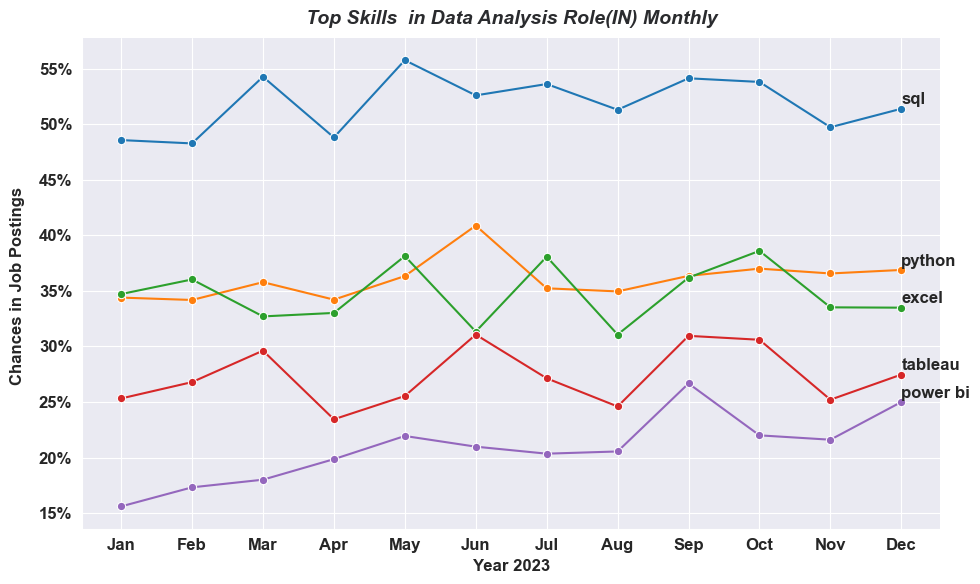

In [29]:
top_skill_percent = df_DA_IN_percent.iloc[:, :5]

plt.rcParams.update({ 'font.weight': 'bold',
                     'font.size': 12,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.labelcolor': "#2A2B2E",
    'text.color': '#2A2B2E',
    'axes.titlecolor': '#2A2B2E',
    'xtick.color': "#2A2B2E",
    'ytick.color': '#2A2B2E',
    'axes.titlesize':14,
    'axes.labelsize':12
    })

plt.figure(figsize=(10, 6))
sns.set_style('darkgrid')

sns.lineplot(data=top_skill_percent, dashes=False, 
             markers='o', legend=False)
sns.despine()

plt.title('Top Skills  in Data Analysis Role(IN) Monthly', fontstyle='italic', pad=10)

plt.ylabel('Chances in Job Postings ', labelpad=10)
plt.xlabel('Year 2023')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:f'{int(y)}%'))

for column in top_skill_percent.columns:
    y = top_skill_percent[column].iloc[-1]
    x = top_skill_percent.index[-1]
    plt.text(x, y + 0.8, column, va='center', ha='left')

plt.tight_layout()
plt.show()

